#### 📚 Importación de librerías


In [ ]:
# Librerias
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.style.use("default")
sns.set_palette("deep")
pd.set_option("display.max_columns", None)


#### ⏫ Importacion de datos


In [ ]:
BASE_DIR = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports" / "03_modeling" / "model_performance"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

processed_files = sorted(PROCESSED_DIR.glob("spotify_model_ready_*.parquet"), key=os.path.getmtime)
if not processed_files:
    raise FileNotFoundError("No se encontraron archivos procesados en data/processed")

latest_processed_path = processed_files[-1]
print("Using processed file:", latest_processed_path)

df = pd.read_parquet(latest_processed_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Using processed file: /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/data/processed/spotify_model_ready_20260301_005928.parquet


Shape: (66074, 13)
Columns: ['track_id', 'track_popularity', 'artist_avg_popularity', 'playlist_avg_popularity', 'playlist_popularity_std', 'artist_popularity_std', 'years_since_release', 'album_release_year', 'playlist_track_count', 'artist_track_count', 'artist_avg_duration', 'playlist_avg_duration', 'popular_high']


,track_id,track_popularity,artist_avg_popularity,playlist_avg_popularity,playlist_popularity_std,artist_popularity_std,years_since_release,album_release_year,playlist_track_count,artist_track_count,artist_avg_duration,playlist_avg_duration,popular_high
0,7Dev2VJdJKwIIUdj3lcQl9,73,53.585714,53.695279,19.799138,21.772535,0.062971,2026.0,233.0,70,3.651259,2.59103,1
1,09CnYHiZ5jGT1wr1TXJ9Zt,82,26.609756,53.695279,19.799138,25.557658,2.247775,2023.0,233.0,41,3.695037,2.59103,1
2,2qlqMa0e422LZyGw1J5for,69,26.609756,53.695279,19.799138,25.557658,0.963723,2025.0,233.0,41,3.695037,2.59103,1


#### 🛡️ Validación de contrato de entrada


In [3]:
required_cols = {
    "track_id", "track_popularity", "popular_high",
    "artist_avg_popularity", "playlist_avg_popularity", "playlist_popularity_std",
    "artist_popularity_std", "years_since_release", "album_release_year",
    "playlist_track_count", "artist_track_count", "artist_avg_duration", "playlist_avg_duration"
}

missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise KeyError(f"Faltan columnas requeridas: {missing_cols}")

nulls_total = int(df.isna().sum().sum())
if nulls_total != 0:
    raise ValueError(f"El dataset procesado contiene nulos ({nulls_total})")

target_counts = df["popular_high"].value_counts().sort_index()
target_pct = (df["popular_high"].value_counts(normalize=True).sort_index() * 100).round(2)
print("Target counts:", target_counts.to_dict())
print("Target pct:", target_pct.to_dict())


Target counts: {0: 45479, 1: 20595}
Target pct: {0: 68.83, 1: 31.17}


### ✂️ Split train/test


In [4]:
X = df.drop(columns=["track_id", "track_popularity", "popular_high"])
y = df["popular_high"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("X shape:", X.shape)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train distribution:", y_train.value_counts(normalize=True).round(4).to_dict())


X shape: (66074, 10)
X_train: (52859, 10) | X_test: (13215, 10)
y_train distribution: {0: 0.6883, 1: 0.3117}


### ⚙️ Definición de 5 modelos


In [5]:
model_configs = {
    "Dummy": {
        "estimator": DummyClassifier(strategy="stratified", random_state=42),
        "scale": False,
    },
    "LogisticRegression": {
        "estimator": LogisticRegression(max_iter=2000, random_state=42),
        "scale": True,
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),
        "scale": False,
    },
    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "scale": False,
    },
    "LinearSVM": {
        "estimator": SGDClassifier(loss="log_loss", max_iter=2000, random_state=42),
        "scale": True,
    },
}


def build_model(config):
    if config["scale"]:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", config["estimator"]),
        ])
    return config["estimator"]

models = {name: build_model(cfg) for name, cfg in model_configs.items()}
print("Modelos definidos:", list(models.keys()))


Modelos definidos: ['Dummy', 'LogisticRegression', 'RandomForest', 'GradientBoosting', 'LinearSVM']


### 📏 Evaluación homogénea por modelo


In [6]:
def get_probability_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]

    if hasattr(model, "decision_function"):
        decision = model.decision_function(X_data)
        # Conversión sigmoide para homogeneizar umbral y reportes
        return 1.0 / (1.0 + np.exp(-decision))

    raise AttributeError("El modelo no soporta predict_proba ni decision_function")


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_score = get_probability_scores(model, X_test)
    y_pred = (y_score >= 0.5).astype(int)

    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
    }

    return metrics, y_score, y_pred

results_rows = []
predictions_store = {}

for name, model in models.items():
    metrics, y_score, y_pred = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results_rows.append(metrics)
    predictions_store[name] = {
        "model": model,
        "y_score": y_score,
        "y_pred": y_pred,
    }

results_df = pd.DataFrame(results_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df


,model,roc_auc,pr_auc,f1,precision,recall,accuracy
0,RandomForest,0.943839,0.881818,0.793414,0.785578,0.801408,0.869921
1,GradientBoosting,0.943498,0.880951,0.794560,0.794753,0.794368,0.871964
2,LogisticRegression,0.919163,0.819383,0.749278,0.775871,0.724448,0.848884
3,LinearSVM,0.917879,0.809512,0.755204,0.757324,0.753095,0.847824
4,Dummy,0.496132,0.310061,0.302628,0.306239,0.299102,0.570337


### 🏁 Resultados comparativos


In [7]:
results_df_rounded = results_df.copy()
for col in ["roc_auc", "pr_auc", "f1", "precision", "recall", "accuracy"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded


,model,roc_auc,pr_auc,f1,precision,recall,accuracy
0,RandomForest,0.9438,0.8818,0.7934,0.7856,0.8014,0.8699
1,GradientBoosting,0.9435,0.8810,0.7946,0.7948,0.7944,0.8720
2,LogisticRegression,0.9192,0.8194,0.7493,0.7759,0.7244,0.8489
3,LinearSVM,0.9179,0.8095,0.7552,0.7573,0.7531,0.8478
4,Dummy,0.4961,0.3101,0.3026,0.3062,0.2991,0.5703


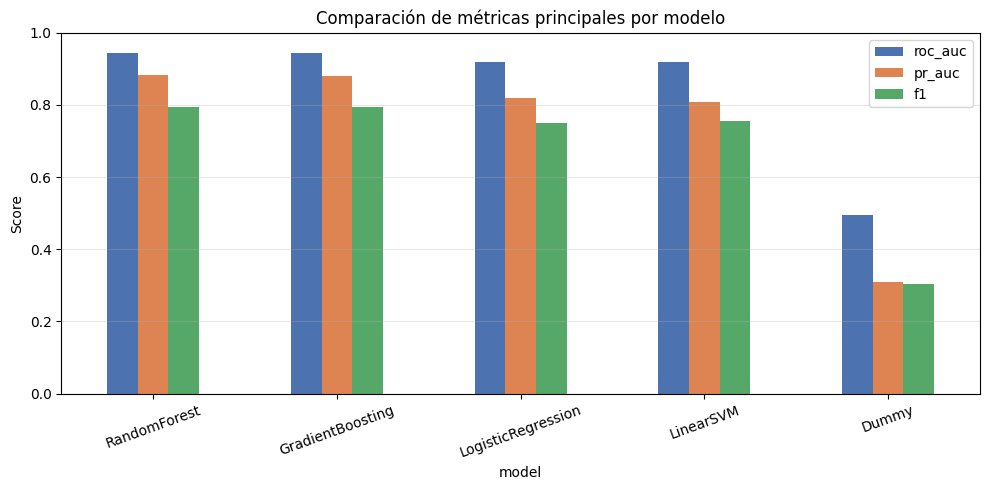

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_df = results_df.set_index("model")[["roc_auc", "pr_auc", "f1"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Comparación de métricas principales por modelo")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


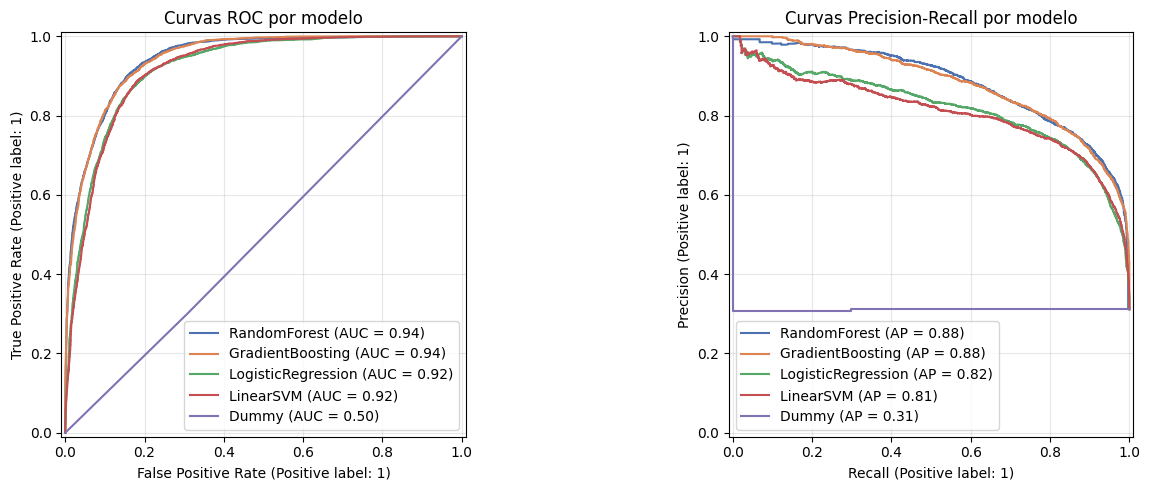

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for _, row in results_df.iterrows():
    name = row["model"]
    y_score = predictions_store[name]["y_score"]
    RocCurveDisplay.from_predictions(y_test, y_score, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=name, ax=axes[1])

axes[0].set_title("Curvas ROC por modelo")
axes[1].set_title("Curvas Precision-Recall por modelo")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 🥇 Análisis del mejor modelo


In [10]:
best_model_name = results_df.iloc[0]["model"]
best_model_obj = predictions_store[best_model_name]["model"]
best_y_score = predictions_store[best_model_name]["y_score"]
best_y_pred = predictions_store[best_model_name]["y_pred"]

print("Best model:", best_model_name)
print("\nClassification report:\n")
print(classification_report(y_test, best_y_pred, digits=4))

cm = confusion_matrix(y_test, best_y_pred)
cm_df = pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])
print("Confusion matrix:")
cm_df


Best model: RandomForest

Classification report:

              precision    recall  f1-score   support

           0     0.9092    0.9009    0.9051      9096
           1     0.7856    0.8014    0.7934      4119

    accuracy                         0.8699     13215
   macro avg     0.8474    0.8512    0.8492     13215
weighted avg     0.8707    0.8699    0.8703     13215

Confusion matrix:


,Pred_0,Pred_1
Actual_0,8195,901
Actual_1,818,3301


In [11]:
def extract_feature_importance(model, feature_names):
    estimator = model.named_steps["model"] if isinstance(model, Pipeline) else model

    if hasattr(estimator, "coef_"):
        values = np.abs(estimator.coef_).ravel()
        return pd.DataFrame({"feature": feature_names, "importance": values}).sort_values("importance", ascending=False)

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        return pd.DataFrame({"feature": feature_names, "importance": values}).sort_values("importance", ascending=False)

    return pd.DataFrame(columns=["feature", "importance"])

feature_importance_df = extract_feature_importance(best_model_obj, X.columns.tolist())
feature_importance_df.head(10)


,feature,importance
0,artist_avg_popularity,0.387428
1,playlist_avg_popularity,0.136863
3,artist_popularity_std,0.105152
4,years_since_release,0.094032
2,playlist_popularity_std,0.064748
7,artist_track_count,0.051690
5,album_release_year,0.047386
8,artist_avg_duration,0.042563
6,playlist_track_count,0.036496
9,playlist_avg_duration,0.033643


### 💾 Export de artefactos y trazabilidad


In [12]:
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

comparison_path = REPORTS_DIR / "model_comparison.csv"
comparison_ts_path = REPORTS_DIR / f"model_comparison_{timestamp}.csv"

predictions_path = REPORTS_DIR / "best_model_test_predictions.csv"
predictions_ts_path = REPORTS_DIR / f"best_model_test_predictions_{timestamp}.csv"

class_report_path = REPORTS_DIR / "best_model_classification_report.csv"
class_report_ts_path = REPORTS_DIR / f"best_model_classification_report_{timestamp}.csv"

conf_matrix_path = REPORTS_DIR / "best_model_confusion_matrix.csv"
conf_matrix_ts_path = REPORTS_DIR / f"best_model_confusion_matrix_{timestamp}.csv"

feature_imp_path = REPORTS_DIR / "best_model_feature_importance.csv"
feature_imp_ts_path = REPORTS_DIR / f"best_model_feature_importance_{timestamp}.csv"

# 1) Tabla de comparación
results_df_rounded.to_csv(comparison_path, index=False)
results_df_rounded.to_csv(comparison_ts_path, index=False)

# 2) Predicciones del mejor modelo
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": best_y_pred,
    "y_score": best_y_score,
})
pred_df.to_csv(predictions_path, index=False)
pred_df.to_csv(predictions_ts_path, index=False)

# 3) Classification report
class_report_df = pd.DataFrame(classification_report(y_test, best_y_pred, output_dict=True)).T
class_report_df.to_csv(class_report_path)
class_report_df.to_csv(class_report_ts_path)

# 4) Confusion matrix
cm_df.to_csv(conf_matrix_path)
cm_df.to_csv(conf_matrix_ts_path)

# 5) Feature importance (si aplica)
if not feature_importance_df.empty:
    feature_importance_df.to_csv(feature_imp_path, index=False)
    feature_importance_df.to_csv(feature_imp_ts_path, index=False)

print("Artifacts exported:")
print(" -", comparison_path)
print(" -", predictions_path)
print(" -", class_report_path)
print(" -", conf_matrix_path)
if not feature_importance_df.empty:
    print(" -", feature_imp_path)


Artifacts exported:
 - /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/reports/03_modeling/model_comparison.csv
 - /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/reports/03_modeling/best_model_test_predictions.csv
 - /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/reports/03_modeling/best_model_classification_report.csv
 - /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/reports/03_modeling/best_model_confusion_matrix.csv
 - /Users/nicoguisande/Library/CloudStorage/OneDri

### 📈 Resumen Ejecutivo de Modelado


In [13]:
print("=" * 80)
print("RESUMEN EJECUTIVO - MODELADO")
print("=" * 80)

print("\n📦 DATASET:")
print(f"  • Archivo procesado: {latest_processed_path.name}")
print(f"  • Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"  • Features para modelado: {X.shape[1]}")
print(f"  • Target distribución: {target_counts.to_dict()} | %: {target_pct.to_dict()}")

print("\n🤖 MODELOS EVALUADOS:")
for m in models.keys():
    print(f"  • {m}")

print("\n🏁 MEJOR MODELO:")
best_row = results_df.iloc[0]
print(f"  • Modelo: {best_model_name}")
print(f"  • ROC-AUC: {best_row['roc_auc']:.4f}")
print(f"  • PR-AUC: {best_row['pr_auc']:.4f}")
print(f"  • F1: {best_row['f1']:.4f}")
print(f"  • Precision: {best_row['precision']:.4f}")
print(f"  • Recall: {best_row['recall']:.4f}")
print(f"  • Accuracy: {best_row['accuracy']:.4f}")

print("\n📁 ARTEFACTOS:")
print(f"  • Comparación modelos: {comparison_path.name}")
print(f"  • Predicciones mejor modelo: {predictions_path.name}")
print(f"  • Classification report: {class_report_path.name}")
print(f"  • Confusion matrix: {conf_matrix_path.name}")
if not feature_importance_df.empty:
    print(f"  • Feature importance: {feature_imp_path.name}")

print("=" * 80)


RESUMEN EJECUTIVO - MODELADO

📦 DATASET:
  • Archivo procesado: spotify_model_ready_20260301_005928.parquet
  • Shape: 66,074 filas x 13 columnas
  • Features para modelado: 10
  • Target distribución: {0: 45479, 1: 20595} | %: {0: 68.83, 1: 31.17}

🤖 MODELOS EVALUADOS:
  • Dummy
  • LogisticRegression
  • RandomForest
  • GradientBoosting
  • LinearSVM

🏁 MEJOR MODELO:
  • Modelo: RandomForest
  • ROC-AUC: 0.9438
  • PR-AUC: 0.8818
  • F1: 0.7934
  • Precision: 0.7856
  • Recall: 0.8014
  • Accuracy: 0.8699

📁 ARTEFACTOS:
  • Comparación modelos: model_comparison.csv
  • Predicciones mejor modelo: best_model_test_predictions.csv
  • Classification report: best_model_classification_report.csv
  • Confusion matrix: best_model_confusion_matrix.csv
  • Feature importance: best_model_feature_importance.csv
